# Oxygen Evals: Hood Canal-Sisters Point-Lynch Cove

In [15]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt


In [16]:
# Constants

Sister_Point = [67, 76, 100, 120]
Twanoh = [67, 76, 129, 140]

PC_ENT = [213, 215, 279, 281]
PC_PNN001 = [213, 215, 276, 278]
PC_CW = [213, 215, 271, 275]
PC_WEST = [215, 217, 268, 271]

idepth = 0
jdepth = 39

obsn = 'Oxygen_Dissolved'
modn = 'mod_dissolved_oxygen'


In [17]:
with xr.open_dataset('/ocean/atall/MOAD/grid/mesh_mask_202310b.nc') as mesh:
    deptht = mesh.gdept_1d[0].values
    tmask0 = mesh.tmask
    mbathy0 = mesh.mbathy
    long = mesh.nav_lon
    latg = mesh.nav_lat
with xr.open_dataset('/ocean/atall/MOAD/grid/bathymetry_202310b.nc') as bath:
    bathy = bath.Bathymetry

In [18]:
def read_pieces(pieces):
    temp1 = pd.read_csv(pieces[0])
    for piece in pieces[1:]:
        nextpiece = pd.read_csv(piece)
        if 'ferry' in piece:
            nextpiece['k'] = 0
        temp1 = pd.concat([temp1, nextpiece], ignore_index=True)
    return temp1

In [19]:
def stats_and_plotLC(years, idepth, jdepth, box1, boxname1, box2, boxname2, whichdepths):
    fig, axs = plt.subplots(1, 2, figsize=(8, 4.5))
    #fig.suptitle(f'{boxname2} Year {years[0]}-{years[-1]}')
    
    pieces1 = []
    for year in years:
        pieces1.append(
              f'/ocean/atall/MOAD/ObsModel/202410bdaily/ObsModel_202410b_eco_from_parker_{year}0101_{year}1231.csv')
    temp1 = read_pieces(pieces1)

    plot_profilesLC(temp1, axs[0], axs[1], box1, boxname1, box2, boxname2)

def stats_and_plotPC(years, idepth, jdepth, box1, boxname1, box2, boxname2, box3, boxname3, box4, boxname4, whichdepths):
    fig, axs = plt.subplots(1, 2, figsize=(8, 4.5))
    
    pieces1 = []
    for year in years:
        pieces1.append(
              f'/ocean/atall/MOAD/ObsModel/202410bdaily/ObsModel_202410b_from_KC_{year}0101_{year}1231.csv')
    temp1 = read_pieces(pieces1)

    plot_profilesPC(temp1, axs[0], axs[1], box1, boxname1, box2, boxname2, box3, boxname3, box4, boxname4)

def stats_and_plotLCPC(yearsl, yearsp, idepth, jdepth, boxl1, boxnamel1, boxl2, boxnamel2, boxp1, boxnamep1, boxp2, boxnamep2, boxp3, boxnamep3, boxp4, boxnamep4, whichdepths):
    fig, axs = plt.subplots(1, 2, figsize=(8, 4.5))

    pieces1 = []
    for year in yearsl:
        pieces1.append(
              f'/ocean/atall/MOAD/ObsModel/202410bdaily/ObsModel_202410b_eco_from_parker_{year}0101_{year}1231.csv')
    temp1 = read_pieces(pieces1)
    
    pieces2 = []
    for year in yearsp:
        pieces2.append(
              f'/ocean/atall/MOAD/ObsModel/202410bdaily/ObsModel_202410b_from_KC_{year}0101_{year}1231.csv')
    temp2 = read_pieces(pieces2)

    plot_profilesLCPC(temp1, temp2, axs[0], axs[1], boxl1, boxnamel1, boxl2, boxnamel2, boxp1, boxnamep1, boxp2, boxnamep2, boxp3, boxnamep3, boxp4, boxnamep4)


In [20]:
def plot_profilesLC(temp1, ax, ax2, box1, boxname1, box2, boxname2):

    corn1 = box1
    corn2 = box2
#    temp1['diff'] = temp1[modn] - temp1[obsn]
    select1 = temp1[(temp1.k >= idepth) & (temp1.k <= jdepth) &
                              (temp1.j >= corn1[0]) & (temp1.j <= corn1[1]) &
                              (temp1.i >= corn1[2]) & (temp1.i <= corn1[3]) &
                              (temp1[obsn] == temp1[obsn])]
    select2 = temp1[(temp1.k >= idepth) & (temp1.k <= jdepth) &
                              (temp1.j >= corn2[0]) & (temp1.j <= corn2[1]) &
                              (temp1.i >= corn2[2]) & (temp1.i <= corn2[3]) &
                              (temp1[obsn] == temp1[obsn])]
    selectZ1 = temp1[(temp1.Z >= 0) & (temp1.Z <= 100) &
                              (temp1.j >= corn1[0]) & (temp1.j <= corn1[1]) &
                              (temp1.i >= corn1[2]) & (temp1.i <= corn1[3]) &
                              (temp1[obsn] == temp1[obsn])]
    selectZ2 = temp1[(temp1.Z >= 0) & (temp1.Z <= 100) &
                              (temp1.j >= corn2[0]) & (temp1.j <= corn2[1]) &
                              (temp1.i >= corn2[2]) & (temp1.i <= corn2[3]) &
                              (temp1[obsn] == temp1[obsn])]
    ks1 = (select1.groupby('k')[obsn].mean().index[:])
    ks2 = (select2.groupby('k')[obsn].mean().index[:])
    zs1 = select1.groupby('Z')[obsn].mean().values
    zs2 = select2.groupby('Z')[obsn].mean().values

    p, = ax.plot(select1.groupby('k')[obsn].mean(), deptht[ks1], '-', label=f'{boxname1} Obs')
    color = p.get_color()
    ax.plot(select1.groupby('k')[modn].mean(), deptht[ks1], '--', c=color, label=f'{boxname1} Model')
    ax.plot(select2.groupby('k')[obsn].mean(), deptht[ks2], '-', c='tab:orange', label=f'{boxname2} Obs')
    ax.plot(select2.groupby('k')[modn].mean(), deptht[ks2], '--', c='tab:orange', label=f'{boxname2} Model')

    p, = ax2.plot(selectZ1.groupby('Z')[obsn].mean(), selectZ1.groupby('Z')[obsn].mean().index[:], '-', label=f'{boxname1} Obs')
    color = p.get_color()
    ax2.plot(selectZ1.groupby('Z')[modn].mean(), selectZ1.groupby('Z')[modn].mean().index[:], '--', c=color, label=f'{boxname1} Model')
    ax2.plot(selectZ2.groupby('Z')[obsn].mean(), selectZ2.groupby('Z')[obsn].mean().index[:], '-', c='tab:orange', label=f'{boxname2} Obs')
    ax2.plot(selectZ2.groupby('Z')[modn].mean(), selectZ2.groupby('Z')[modn].mean().index[:], '--', c='tab:orange', label=f'{boxname2} Model')

   
    ax.invert_yaxis()
    ax2.invert_yaxis()
    ax.set_ylim(55, 0)  
    ax2.set_ylim(55, 0) 
    ax.set_ylabel('Depth (m)')
    ax.set_xlabel('DO (mmol m$^{-3}$)')
    ax2.set_xlabel('DO (mmol m$^{-3}$)')

    ax.legend()
    ax.grid()
    ax2.grid()

def plot_profilesPC(temp1, ax, ax2, box1, boxname1, box2, boxname2, box3, boxname3, box4, boxname4):

    corn1 = box1
    corn2 = box2
    corn3 = box3
    corn4 = box4
    select1 = temp1[(temp1.k >= idepth) & (temp1.k <= jdepth) &
                              (temp1.j >= corn1[0]) & (temp1.j <= corn1[1]) &
                              (temp1.i >= corn1[2]) & (temp1.i <= corn1[3]) &
                              (temp1[obsn] == temp1[obsn])]
    select2 = temp1[(temp1.k >= idepth) & (temp1.k <= jdepth) &
                              (temp1.j >= corn2[0]) & (temp1.j <= corn2[1]) &
                              (temp1.i >= corn2[2]) & (temp1.i <= corn2[3]) &
                              (temp1[obsn] == temp1[obsn])]
    
    select3 = temp1[(temp1.k >= idepth) & (temp1.k <= jdepth) &
                              (temp1.j >= corn3[0]) & (temp1.j <= corn3[1]) &
                              (temp1.i >= corn3[2]) & (temp1.i <= corn3[3]) &
                              (temp1[obsn] == temp1[obsn])]
    select4 = temp1[(temp1.k >= idepth) & (temp1.k <= jdepth) &
                              (temp1.j >= corn4[0]) & (temp1.j <= corn4[1]) &
                              (temp1.i >= corn4[2]) & (temp1.i <= corn4[3]) &
                              (temp1[obsn] == temp1[obsn])]
    selectZ1 = temp1[(temp1.k >= 0) & (temp1.k <= 100) &
                              (temp1.j >= corn1[0]) & (temp1.j <= corn1[1]) &
                              (temp1.i >= corn1[2]) & (temp1.i <= corn1[3]) &
                              (temp1[obsn] == temp1[obsn])]
    selectZ2 = temp1[(temp1.k >= 0) & (temp1.k <= 100) &
                              (temp1.j >= corn2[0]) & (temp1.j <= corn2[1]) &
                              (temp1.i >= corn2[2]) & (temp1.i <= corn2[3]) &
                              (temp1[obsn] == temp1[obsn])]
    
    selectZ3 = temp1[(temp1.k >= 0) & (temp1.k <= 100) &
                              (temp1.j >= corn3[0]) & (temp1.j <= corn3[1]) &
                              (temp1.i >= corn3[2]) & (temp1.i <= corn3[3]) &
                              (temp1[obsn] == temp1[obsn])]
    selectZ4 = temp1[(temp1.k >= 0) & (temp1.k <= 100) &
                              (temp1.j >= corn4[0]) & (temp1.j <= corn4[1]) &
                              (temp1.i >= corn4[2]) & (temp1.i <= corn4[3]) &
                              (temp1[obsn] == temp1[obsn])]

    ks1 = (select1.groupby('k')[obsn].mean().index[:])
    ks2 = (select2.groupby('k')[obsn].mean().index[:])
    ks3 = (select3.groupby('k')[obsn].mean().index[:])
    ks4 = (select4.groupby('k')[obsn].mean().index[:])

    p, = ax.plot(select1.groupby('k')[obsn].mean(), deptht[ks1], '-', label=f'Obs-{boxname1}')
    color = p.get_color()
    ax.plot(select1.groupby('k')[modn].mean(), deptht[ks1], '--', c=color, label=f'Model-{boxname1}')
    ax.plot(select2.groupby('k')[obsn].mean(), deptht[ks2], '-', c='tab:orange', label=f'Obs-{boxname2}')
    ax.plot(select2.groupby('k')[modn].mean(), deptht[ks2], '--', c='tab:orange', label=f'Model-{boxname2}')
    ax.plot(select3.groupby('k')[obsn].mean(), deptht[ks3], '-', c='tab:green', label=f'Obs-{boxname3}')
    ax.plot(select3.groupby('k')[modn].mean(), deptht[ks3], '--', c='tab:green', label=f'Model-{boxname3}')
    ax.plot(select4.groupby('k')[obsn].mean(), deptht[ks4], '-', c='tab:red', label=f'Obs-{boxname4}')
    ax.plot(select4.groupby('k')[modn].mean(), deptht[ks4], '--', c='tab:red', label=f'Model-{boxname4}')

    p, = ax2.plot(selectZ1.groupby('Z')[obsn].mean(), selectZ1.groupby('Z')[obsn].mean().index, '-', label=f'Obs-{boxname1}')
    color = p.get_color()
    ax2.plot(selectZ1.groupby('Z')[modn].mean(), selectZ1.groupby('Z')[modn].mean().index, '--', c=color, label=f'Model-{boxname1}')
    ax2.plot(selectZ2.groupby('Z')[obsn].mean(), selectZ2.groupby('Z')[obsn].mean().index, '-', c='tab:orange', label=f'Obs-{boxname2}')
    ax2.plot(selectZ2.groupby('Z')[modn].mean(), selectZ2.groupby('Z')[modn].mean().index, '--', c='tab:orange', label=f'Model-{boxname2}')
    ax2.plot(selectZ3.groupby('Z')[obsn].mean(), selectZ3.groupby('Z')[obsn].mean().index, '-', c='tab:green', label=f'Obs-{boxname3}')
    ax2.plot(selectZ3.groupby('Z')[modn].mean(), selectZ3.groupby('Z')[modn].mean().index, '--', c='tab:green', label=f'Model-{boxname3}')
    ax2.plot(selectZ4.groupby('Z')[obsn].mean(), selectZ4.groupby('Z')[obsn].mean().index, '-', c='tab:red', label=f'Obs-{boxname4}')
    ax2.plot(selectZ4.groupby('Z')[modn].mean(), selectZ4.groupby('Z')[modn].mean().index, '--', c='tab:red', label=f'Model-{boxname4}')

    ax.invert_yaxis()
    ax2.invert_yaxis()
    ax.set_ylim(30, 0)  
    ax2.set_ylim(30, 0)
    
    ax.set_ylabel('Depth (m)')
    ax.set_xlabel('DO (mmol m$^{-3}$)')
    ax2.set_xlabel('DO (mmol m$^{-3}$)')

    ax.legend()
    ax.grid()
    ax2.grid()

def plot_profilesLCPC(temp1, temp2, ax1, ax2, boxl1, boxnamel1, boxl2, boxnamel2, boxp1, boxnamep1, boxp2, boxnamep2, boxp3, boxnamep3, boxp4, boxnamep4):

    cornl1 = boxl1
    cornl2 = boxl2
    cornp1 = boxp1
    cornp2 = boxp2
    cornp3 = boxp3
    cornp4 = boxp4
    selectl1 = temp1[(temp1.k >= idepth) & (temp1.k <= jdepth) &
                              (temp1.j >= cornl1[0]) & (temp1.j <= cornl1[1]) &
                              (temp1.i >= cornl1[2]) & (temp1.i <= cornl1[3]) &
                              (temp1[obsn] == temp1[obsn])]
    selectl2 = temp1[(temp1.k >= idepth) & (temp1.k <= jdepth) &
                              (temp1.j >= cornl2[0]) & (temp1.j <= cornl2[1]) &
                              (temp1.i >= cornl2[2]) & (temp1.i <= cornl2[3]) &
                              (temp1[obsn] == temp1[obsn])]
    
    selectp1 = temp2[(temp2.k >= idepth) & (temp2.k <= jdepth) &
                              (temp2.j >= cornp1[0]) & (temp2.j <= cornp1[1]) &
                              (temp2.i >= cornp1[2]) & (temp2.i <= cornp1[3]) &
                              (temp2[obsn] == temp2[obsn])]
    selectp2 = temp2[(temp2.k >= idepth) & (temp2.k <= jdepth) &
                              (temp2.j >= cornp2[0]) & (temp2.j <= cornp2[1]) &
                              (temp2.i >= cornp2[2]) & (temp2.i <= cornp2[3]) &
                              (temp2[obsn] == temp2[obsn])]
    selectp3 = temp2[(temp2.k >= idepth) & (temp2.k <= jdepth) &
                              (temp2.j >= cornp3[0]) & (temp2.j <= cornp3[1]) &
                              (temp2.i >= cornp3[2]) & (temp2.i <= cornp3[3]) &
                              (temp2[obsn] == temp2[obsn])]
    selectp4 = temp2[(temp2.k >= idepth) & (temp2.k <= jdepth) &
                              (temp2.j >= cornp4[0]) & (temp2.j <= cornp4[1]) &
                              (temp2.i >= cornp4[2]) & (temp2.i <= cornp4[3]) &
                              (temp2[obsn] == temp2[obsn])]
    ksl1 = (selectl1.groupby('k')[obsn].mean().index[:])
    ksl2 = (selectl2.groupby('k')[obsn].mean().index[:])
    ksp1 = (selectp1.groupby('k')[obsn].mean().index[:])
    ksp2 = (selectp2.groupby('k')[obsn].mean().index[:])
    ksp3 = (selectp3.groupby('k')[obsn].mean().index[:])
    ksp4 = (selectp4.groupby('k')[obsn].mean().index[:])

    p, = ax1.plot(selectl1.groupby('k')[obsn].mean(), deptht[ksl1], '.-', label=f'Obs-{boxnamel1}')
    color = p.get_color()
    ax1.plot(selectl1.groupby('k')[modn].mean(), deptht[ksl1], '.--', c=color, label=f'Model-{boxnamel1}')
    ax1.plot(selectl2.groupby('k')[obsn].mean(), deptht[ksl2], '.-', c='tab:orange', label=f'Obs-{boxnamel2}')
    ax1.plot(selectl2.groupby('k')[modn].mean(), deptht[ksl2], '.--', c='tab:orange', label=f'Model-{boxnamel2}')

    p, = ax2.plot(selectp1.groupby('k')[obsn].mean(), deptht[ksp1], '.-', label=f'Obs-{boxnamep1}')
    color = p.get_color()
    ax2.plot(selectp1.groupby('k')[modn].mean(), deptht[ksp1], '.--', c=color, label=f'Model-{boxnamep1}')
    ax2.plot(selectp2.groupby('k')[obsn].mean(), deptht[ksp2], '.-', c='tab:orange', label=f'Obs-{boxnamep2}')
    ax2.plot(selectp2.groupby('k')[modn].mean(), deptht[ksp2], '.--', c='tab:orange', label=f'Model-{boxnamep2}')
    ax2.plot(selectp3.groupby('k')[obsn].mean(), deptht[ksp3], '.-', c='tab:purple', label=f'Obs-{boxnamep3}')
    ax2.plot(selectp3.groupby('k')[modn].mean(), deptht[ksp3], '.--', c='tab:purple', label=f'Model-{boxnamep3}')
    ax2.plot(selectp4.groupby('k')[obsn].mean(), deptht[ksp4], '.-', c='tab:brown', label=f'Obs-{boxnamep4}')
    ax2.plot(selectp4.groupby('k')[modn].mean(), deptht[ksp4], '.--', c='tab:brown', label=f'Model-{boxnamep4}')

    print(ksl1.max())
    print(ksl2.max())
    print(ksp1.max())
    print(ksp2.max())
    print(ksp3.max())
    print(ksp4.max())

    ax1.invert_yaxis()
    ax2.invert_yaxis()
    ax1.set_ylim(35.2, 0)
    ax2.set_ylim(35.2, 0)  
    
    ax1.set_ylabel('Depth (m)')
    ax1.set_xlabel('DO (mmol m$^{-3}$)')
    ax2.set_xlabel('DO (mmol m$^{-3}$)')
    ax1.set_title(f'Lynch Cove, 2012-2024')
    ax2.set_title(f'Penn Cove, 2022-2024')

    ax1.legend()
    ax2.legend()
    ax1.grid()
    ax2.grid()


### Plots

22
16
19
20
10
11


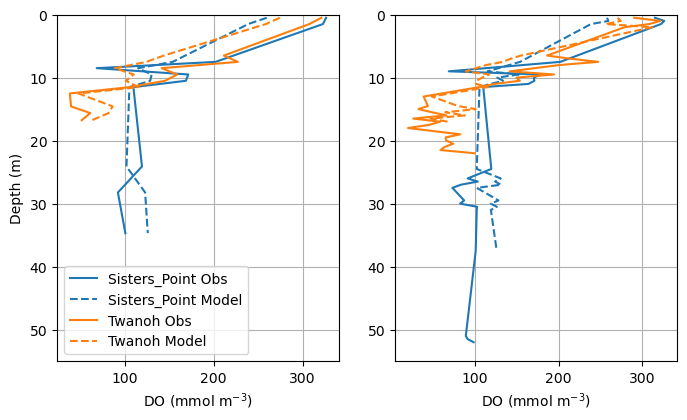

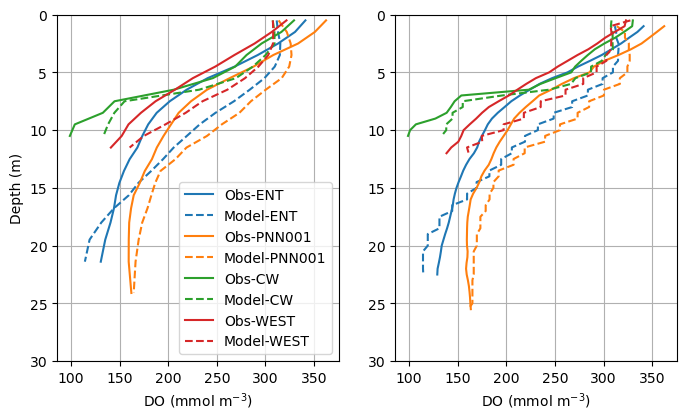

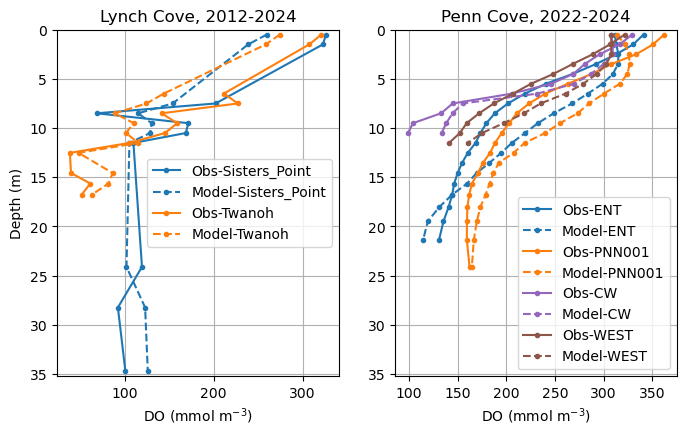

In [21]:
stats_and_plotLC([2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024],
               idepth, jdepth, Sister_Point, 'Sisters_Point', Twanoh, 'Twanoh', 'alldepths')

stats_and_plotPC([2022,2023,2024],
                  idepth, jdepth, PC_ENT, 'ENT', PC_PNN001, 'PNN001', PC_CW, 'CW', PC_WEST, 'WEST', 'alldepths')

stats_and_plotLCPC([2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024], [2022,2023,2024],
                  idepth, jdepth, Sister_Point, 'Sisters_Point', Twanoh, 'Twanoh', PC_ENT, 'ENT', PC_PNN001, 'PNN001', PC_CW, 'CW', PC_WEST, 'WEST', 'alldepths')